# $\mathrm{Ca}_{\mathrm{V}}1.2$ G402S mutation-site distance analysis
Here we compare WT and G402S distance distributions near the G402 mutation site. Candidate distances are selected from CSV columns containing residues within ±4 positions of G402, ranked by the absolute WT-to-G402S median shift, and plotted separately for vanilla and masked protocols. Matching experimental distances are overlaid from the explicitly listed values calculated for the Cav1.2 α-subunit in 8WE6 chain A, 8HLP chain A, and 8FD7 chain K.

The final section focuses on shortest heavy-atom distances made by the introduced S402 side chain. Contact-frequency bars summarize candidate partners, and split violins compare WT G402 with mutant S402. Distances below 2 Å are flagged as atomic overlaps rather than interpreted as interactions.


## Comparison design

WT and G402S are compared separately in vanilla and masked ensembles. Nearby
coordinates are ranked by their WT-to-mutant median shift, while experimental
values from 8WE6, 8HLP, and 8FD7 remain fixed reference points. This separates
the sequence effect from the effect of masking.

In [1]:
from pathlib import Path
import importlib
import sys
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
import shared.mutation_site_analysis as mutation_site_analysis
importlib.reload(mutation_site_analysis)  # Pick up helper changes in an already-running kernel.
load_ensemble = mutation_site_analysis.load_ensemble
nearby_distance_columns = mutation_site_analysis.nearby_distance_columns
rank_nearby_shifts = mutation_site_analysis.rank_nearby_shifts
top_aliases = mutation_site_analysis.top_aliases
plot_nearby_overlay = mutation_site_analysis.plot_nearby_overlay
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv
from shared.plotting import CAV12_PALETTE, plot_top_shifts
G402S_EXPERIMENTAL_DISTANCES = {
    '8WE6 | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [10.070], 'CA_LEU401_CA-VAL753_CA': [11.718], 'GLY406-MET1524': [7.404],
        'LEU401-ALA1521': [9.341], 'LEU401-ASN1526': [9.824], 'LEU401-ASP1525': [10.976], 'LEU401-ASP1528': [11.996], 'LEU401-ASP1533': [14.828],
        'LEU401-MET1524': [8.529], 'LEU401-TYR1529': [10.879], 'LEU401-VAL1522': [8.829], 'LEU404-MET1524': [9.680],
        'SER405-ASP1525': [9.391], 'SER405-ASP1533': [11.521], 'SER405-MET1524': [6.077], 'SER405-TYR1529': [9.355],
        'VAL400-ASP1528': [13.981], 'VAL400-MET1524': [11.185], 'VAL403-ASP1528': [10.703], 'VAL403-MET1524': [9.090],
    },
    '8HLP | chain A': {
        'CA_LEU401_CA-ILE1186_CA': [9.986], 'CA_LEU401_CA-VAL753_CA': [11.751], 'GLY406-MET1524': [8.961],
        'LEU401-ALA1521': [9.471], 'LEU401-ASN1526': [9.889], 'LEU401-ASP1525': [11.505], 'LEU401-ASP1528': [11.921], 'LEU401-ASP1533': [14.849],
        'LEU401-MET1524': [9.147], 'LEU401-TYR1529': [10.943], 'LEU401-VAL1522': [8.975], 'LEU404-MET1524': [11.400],
        'SER405-ASP1525': [9.994], 'SER405-ASP1533': [11.415], 'SER405-MET1524': [7.551], 'SER405-TYR1529': [9.544],
        'VAL400-ASP1528': [14.009], 'VAL400-MET1524': [11.875], 'VAL403-ASP1528': [10.726], 'VAL403-MET1524': [9.957],
    },
    '8FD7 | chain K': {
        'CA_LEU401_CA-ILE1186_CA': [13.653], 'CA_LEU401_CA-VAL753_CA': [15.182], 'GLY406-MET1524': [13.416],
        'LEU401-ALA1521': [7.614], 'LEU401-ASN1526': [3.233], 'LEU401-ASP1525': [7.669], 'LEU401-ASP1528': [8.778], 'LEU401-ASP1533': [11.673],
        'LEU401-MET1524': [6.187], 'LEU401-TYR1529': [8.138], 'LEU401-VAL1522': [5.311], 'LEU404-MET1524': [8.234],
        'SER405-ASP1525': [11.258], 'SER405-ASP1533': [7.884], 'SER405-MET1524': [10.802], 'SER405-TYR1529': [6.804],
        'VAL400-ASP1528': [13.343], 'VAL400-MET1524': [11.054], 'VAL403-ASP1528': [13.659], 'VAL403-MET1524': [13.091],
    },
}
G402S_EXPERIMENTAL_DISTANCES


{'8WE6 | chain A': {'CA_LEU401_CA-ILE1186_CA': [10.07],
  'CA_LEU401_CA-VAL753_CA': [11.718],
  'GLY406-MET1524': [7.404],
  'LEU401-ALA1521': [9.341],
  'LEU401-ASN1526': [9.824],
  'LEU401-ASP1525': [10.976],
  'LEU401-ASP1528': [11.996],
  'LEU401-ASP1533': [14.828],
  'LEU401-MET1524': [8.529],
  'LEU401-TYR1529': [10.879],
  'LEU401-VAL1522': [8.829],
  'LEU404-MET1524': [9.68],
  'SER405-ASP1525': [9.391],
  'SER405-ASP1533': [11.521],
  'SER405-MET1524': [6.077],
  'SER405-TYR1529': [9.355],
  'VAL400-ASP1528': [13.981],
  'VAL400-MET1524': [11.185],
  'VAL403-ASP1528': [10.703],
  'VAL403-MET1524': [9.09]},
 '8HLP | chain A': {'CA_LEU401_CA-ILE1186_CA': [9.986],
  'CA_LEU401_CA-VAL753_CA': [11.751],
  'GLY406-MET1524': [8.961],
  'LEU401-ALA1521': [9.471],
  'LEU401-ASN1526': [9.889],
  'LEU401-ASP1525': [11.505],
  'LEU401-ASP1528': [11.921],
  'LEU401-ASP1533': [14.849],
  'LEU401-MET1524': [9.147],
  'LEU401-TYR1529': [10.943],
  'LEU401-VAL1522': [8.975],
  'LEU404-MET1524'

In [2]:
from shared.presentation_export import install_notebook_figure_export
WRITING_FIGURE_DIR = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'cav12'
install_notebook_figure_export(WRITING_FIGURE_DIR, 'Cav12_G402S_mutationSite_analysis')


PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/cav12/Cav12_G402S_mutationSite_analysis')

In [3]:
DATASET_SELECTION = 'all_ok_3'  # Corrected 3 Å convergence subset stored in cav12/dataDistances; switch to 'all' to inspect unfiltered rows.
data = repo_root / 'cav12' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    'G402S vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_vanillaAF2_distances_all.csv', 'Cav12', 'G402S', 'vanilla'),
    'G402S masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_maskedAF2_distances_all.csv', 'Cav12', 'G402S', 'masked'),
}
DATASET_PATHS
wt_van = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
wt_mask = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
mut_van = load_selected_distance_csv('G402S vanilla', DATASET_PATHS['G402S vanilla'], DATASET_SELECTION)
mut_mask = load_selected_distance_csv('G402S masked', DATASET_PATHS['G402S masked'], DATASET_SELECTION)
structures = {'8WE6 | chain A': (repo_root / 'cav12' / 'experimentals' / '8WE6.pdb', 'A'), '8HLP | chain A': (repo_root / 'cav12' / 'experimentals' / '8HLP.pdb', 'A'), '8FD7 | chain K': (repo_root / 'cav12' / 'experimentals' / '8FD7.pdb', 'K')}
experimental_colors = None  # shared PDB-specific colors and markers


WT vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv
WT masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv


G402S vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv
G402S masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv


## Mutation-centered distances and shortest-contact analysis

The Cα panels describe mutation-neighborhood geometry. The shortest-distance analysis then asks whether the introduced side chain approaches specific partners differently in vanilla and masked ensembles. Distances from 2–4 Å are summarized as geometrically plausible contacts; values below 2 Å are kept separate because they more likely indicate atomic overlap and require inspection of the underlying structures.


,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
15,shortest_VAL400-MET1524,10.9,12.0,1.1,1.1
100,shortest_GLY406-MET1524,6.5,7.5,1.0,1.0
33,shortest_LEU401-ASP1525,14.4,13.4,-1.0,1.0
29,shortest_LEU401-ALA1521,9.9,8.9,-1.0,1.0
36,shortest_LEU401-ASP1528,12.3,11.6,-0.7,0.7
30,shortest_LEU401-VAL1522,13.3,12.6,-0.7,0.7
32,shortest_LEU401-MET1524,6.7,6.0,-0.7,0.7
19,shortest_VAL400-ASP1528,14.1,13.4,-0.7,0.7
37,shortest_LEU401-TYR1529,22.2,21.5,-0.7,0.7
49,shortest_VAL403-MET1524,9.4,10.0,0.6,0.6


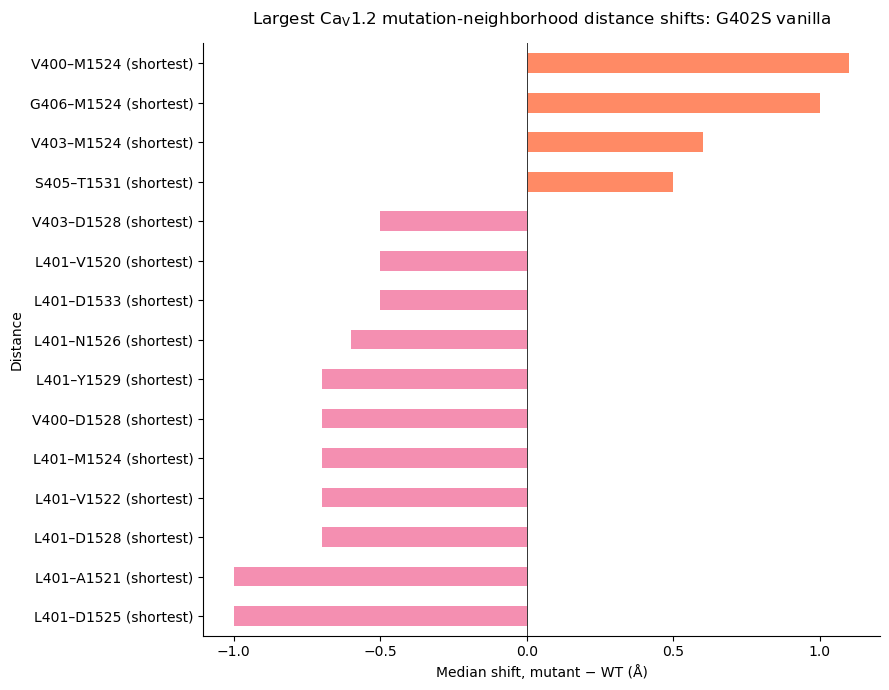

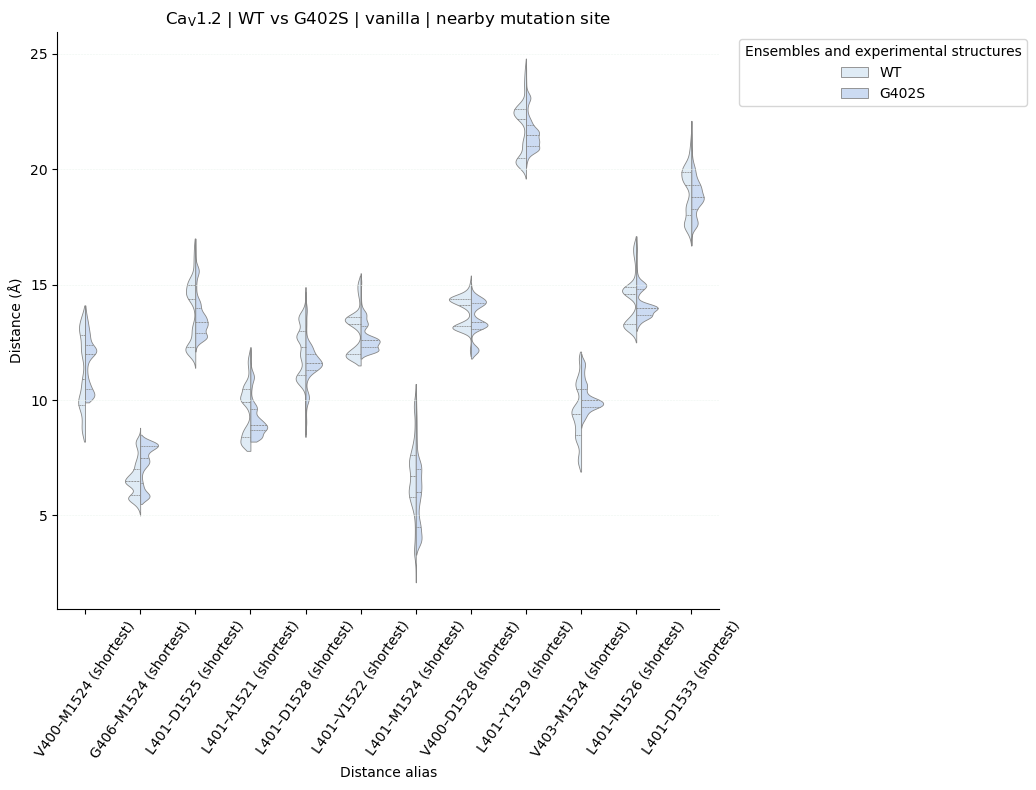

,distance,wt_median_A,mutant_median_A,median_shift_A,abs_shift_A
15,shortest_VAL400-MET1524,10.40,12.60,2.20,2.20
49,shortest_VAL403-MET1524,8.30,10.00,1.70,1.70
100,shortest_GLY406-MET1524,5.80,7.20,1.40,1.40
66,shortest_LEU404-MET1524,9.70,10.80,1.10,1.10
83,shortest_SER405-MET1524,4.00,4.90,0.90,0.90
1,CA_LEU401_CA-VAL753_CA,12.06,12.92,0.86,0.86
4,CA_LEU401_CA-ILE1186_CA,13.01,13.64,0.63,0.63
0,CA_LEU401_CA-LEU749_CA,9.05,9.65,0.60,0.60
92,shortest_SER405-ASP1533,14.80,15.40,0.60,0.60
29,shortest_LEU401-ALA1521,11.10,11.70,0.60,0.60


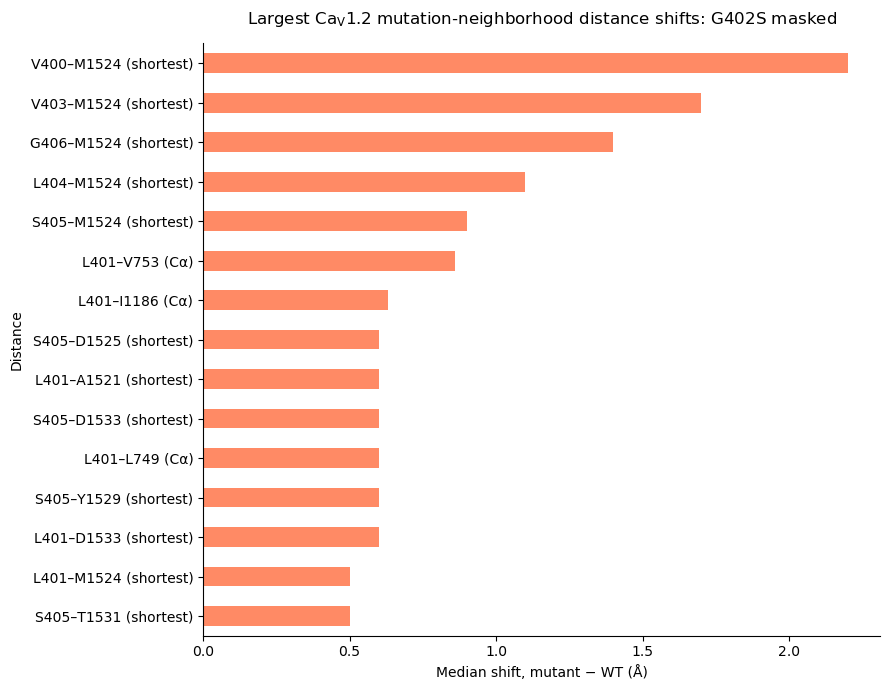

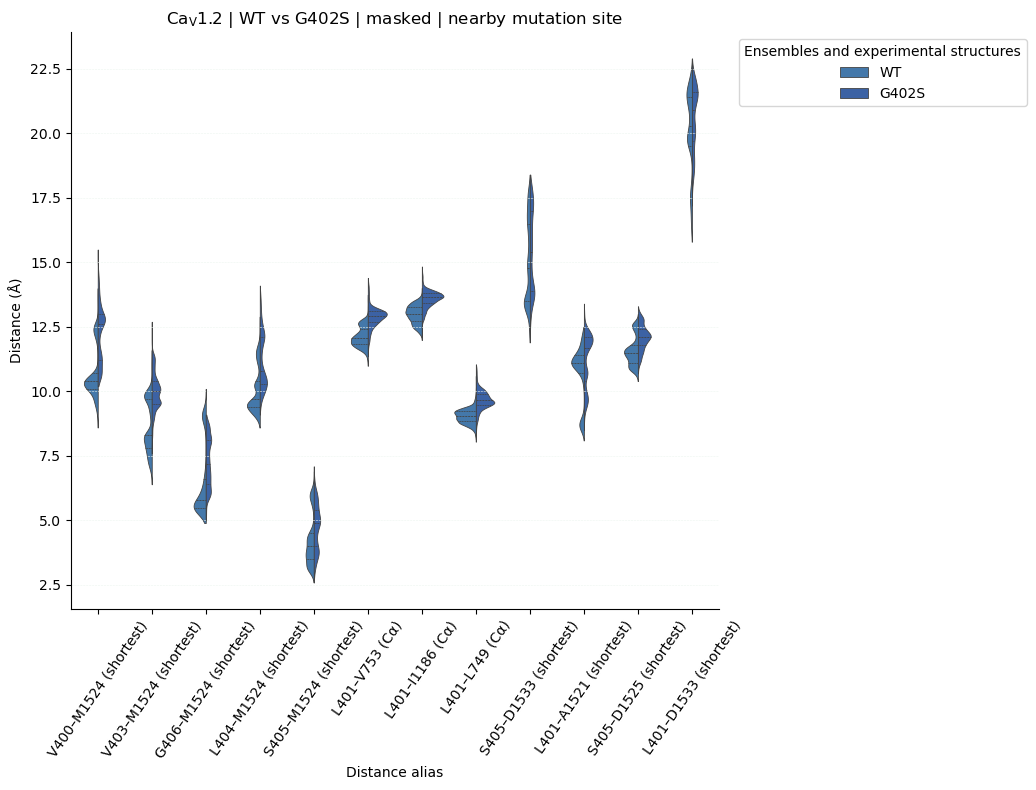

,Protocol,Mutant residue,Partner,n,Median (Å),5th percentile (Å),95th percentile (Å),Plausible contact 2–4 Å,Atomic overlap <2 Å,Shortest distance ≤4 Å,Masked − vanilla median (Å),Masked − vanilla plausible-contact fraction,Masked − vanilla overlap fraction,Contact interpretation
4,vanilla,SER402,ILE1523,5000,4.80,3.700,5.9,0.192,0.0,0.192,0.00,-0.071,0.0,recurrent plausible contact
24,masked,SER402,ILE1523,4995,4.80,3.800,6.9,0.121,0.0,0.121,0.00,-0.071,0.0,recurrent plausible contact
21,masked,SER402,VAL1520,4995,5.80,4.200,7.9,0.024,0.0,0.024,0.00,0.024,0.0,rare plausible contact
25,masked,SER402,MET1524,4995,5.20,4.300,6.4,0.016,0.0,0.016,-0.60,0.016,0.0,rare plausible contact
9,vanilla,SER402,ASP1528,5000,6.60,4.200,8.6,0.010,0.0,0.010,0.30,-0.009,0.0,rare plausible contact
29,masked,SER402,ASP1528,4995,6.90,4.800,9.2,0.001,0.0,0.001,0.30,-0.009,0.0,rare plausible contact
1,vanilla,SER402,VAL1520,5000,5.80,5.000,8.1,0.000,0.0,0.000,0.00,0.024,0.0,rare plausible contact
5,vanilla,SER402,MET1524,5000,5.80,4.900,6.9,0.000,0.0,0.000,-0.60,0.016,0.0,rare plausible contact
28,masked,SER402,PHE1527,4995,6.20,5.200,7.6,0.000,0.0,0.000,-0.30,0.000,0.0,no sampled contact
8,vanilla,SER402,PHE1527,5000,6.50,4.800,7.4,0.000,0.0,0.000,-0.30,0.000,0.0,no sampled contact


,Structure,State,Chain,Raw site,Site identity,Site PDB residue,Partner,Partner PDB residue,Shortest distance (Å)
0,8WE6,WT experimental,A,402,G,402,ILE1523,1523,3.354
1,8WE6,WT experimental,A,402,G,402,VAL1520,1520,7.855
2,8WE6,WT experimental,A,402,G,402,MET1524,1524,7.004
3,8WE6,WT experimental,A,402,G,402,ASP1528,1528,9.172
4,8HLP,WT experimental,A,402,G,402,ILE1523,1523,3.185
5,8HLP,WT experimental,A,402,G,402,VAL1520,1520,8.155
6,8HLP,WT experimental,A,402,G,402,MET1524,1524,7.826
7,8HLP,WT experimental,A,402,G,402,ASP1528,1528,9.259
8,8FD7,WT experimental,K,402,G,402,ILE1523,1475,8.232
9,8FD7,WT experimental,K,402,G,402,VAL1520,1472,11.491


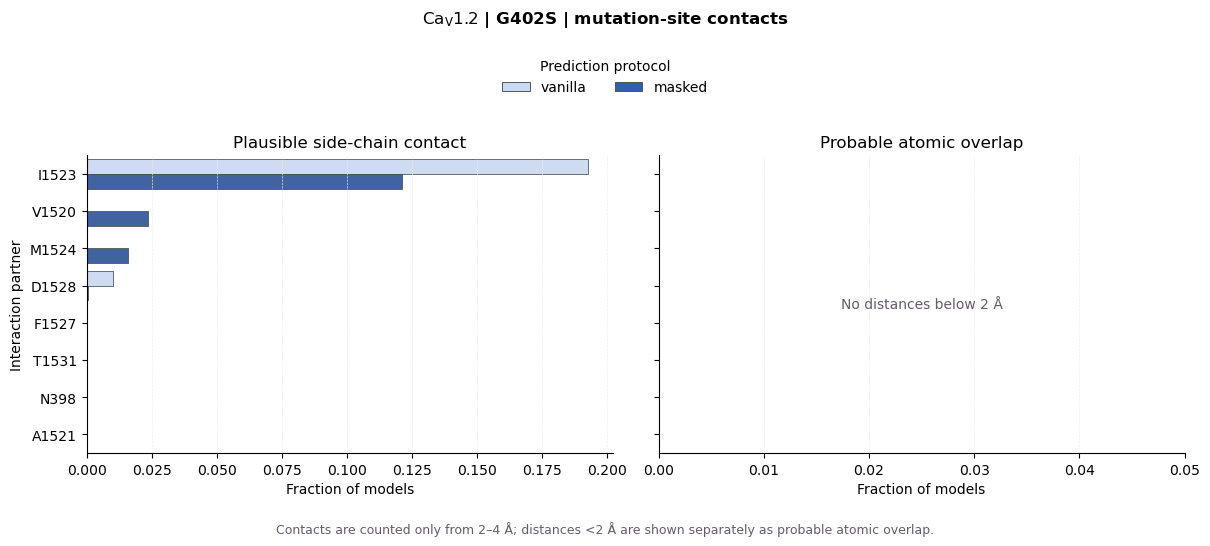

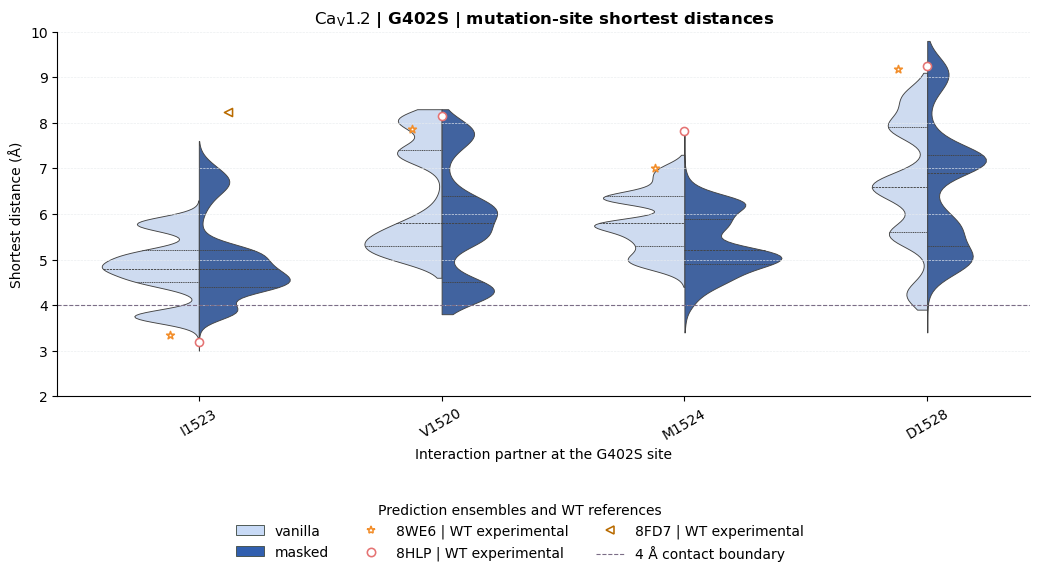

In [4]:
for protocol, wt, mutant, colors in [('vanilla', wt_van, mut_van, (CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G402S_VAN'])), ('masked', wt_mask, mut_mask, (CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G402S_HM']))]:
    shifts = rank_nearby_shifts(wt, mutant, nearby_distance_columns(wt, 402))
    display(shifts.head(20))
    if shifts.empty:
        print(f'No complete WT–G402S paired distances are available for {protocol}; skipping the ranked-shift overlay.')
        continue
    plot_top_shifts(shifts, f'Largest Cav1.2 mutation-neighborhood distance shifts: G402S {protocol}')
    aliases = top_aliases(shifts)
    experimentals = {structure: {alias: values for alias, values in distances.items() if alias in aliases} for structure, distances in G402S_EXPERIMENTAL_DISTANCES.items()}
    plot_nearby_overlay(wt, mutant, aliases, 'Cav1.2', 'G402S', protocol, colors, experimentals, experimental_colors)

## Protocol-resolved contacts made by the introduced SER402 side chain
from shared.mutation_contact_analysis import (
    plot_mutation_protocol_contacts,
    plot_mutant_contact_distributions,
    cav12_experimental_shortest_distances,
)

contact_frames = {'vanilla': mut_van, 'masked': mut_mask}
contact_colors = {
    'vanilla': CAV12_PALETTE['G402S_VAN'],
    'masked': CAV12_PALETTE['G402S_HM'],
}
g402s_contact_table, g402s_contact_sources, g402s_contact_figure = plot_mutation_protocol_contacts(
    contact_frames,
    'SER402',
    'G402S',
    contact_colors,
    channel='Cav1.2',
)
display(g402s_contact_table.round(3))

table_dir = repo_root / 'cav12' / 'dataDistances' / 'analysis' / 'tables'
figure_dir = repo_root / 'cav12' / 'dataDistances' / 'analysis' / 'figures'
table_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
g402s_contact_table.to_csv(table_dir / 'g402s_mutation_site_contacts.csv', index=False)
g402s_contact_sources.to_csv(table_dir / 'g402s_mutation_site_contact_sources.csv', index=False)
g402s_contact_figure.savefig(figure_dir / 'g402s_mutation_site_contact_frequencies.png', dpi=400, bbox_inches='tight')

g402s_experimental_shortest = cav12_experimental_shortest_distances(
    repo_root, raw_site=402, partners=['ILE1523', 'VAL1520', 'MET1524', 'ASP1528']
)
display(g402s_experimental_shortest.round(3))
g402s_experimental_shortest.to_csv(
    table_dir / 'g402s_experimental_wt_shortest_distances.csv', index=False
)

g402s_contact_distributions, g402s_distribution_figure = plot_mutant_contact_distributions(
    contact_frames,
    'SER402',
    'G402S',
    contact_colors,
    partners=['ILE1523', 'VAL1520', 'MET1524', 'ASP1528'],
    channel='Cav1.2',
    experimental_distances=g402s_experimental_shortest,
)
g402s_distribution_figure.savefig(figure_dir / 'g402s_mutation_site_contact_distributions.png', dpi=400, bbox_inches='tight')
